In [2]:
import choix
import pandas as pd
import json
import ast
from enum import Enum
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx
from itertools import permutations
import itertools
from collections import Counter
from dataclasses import dataclass

In [3]:
df = pd.read_csv("data/subjective-persuasiveness-prolific-results.csv", sep="|")

In [4]:
df.head()

,Unnamed: 0,DataPoint_ID,Task_Group_ID,Task_Type,Question,Debate Topic,Debate 1,Debate 2,META_SAMPLE1_POLITICAL_POSITION,META_SAMPLE1_SPEAKERA,...,META_ATTEN_CHECK_PERSUASIVENESS_ANSWER,META_ATTEN_CHECK_CONFIDENCE_ANSWER,META_SAMPLE1_DIALOGUE_CHUNK,META_PAIR_SESSION_IDS,META_SAMPLE2_POLITICAL_POSITION,sample1_win_count,sample2_win_count,average_confidence,std_confidence,confidence_values
0,0,019c5684-b730-70dd-b5f3-ca369d6a622c,412,multiple_choice,"Based only on the debate transcripts, which Sp...",Debate the trade-offs of government interventi...,"Speaker A: ""How can this be done if the opport...","Speaker A: ""Would you concur that this point r...",left,human_9,...,NaN,NaN,"[{'speaker': 'human_9', 'timestamp': '2026-01-...","('XZV57F', 'OR2XBB')",left,6.0,1.0,3.714286,1.112697,"[3, 4, 5, 2, 3, 5, 4]"
1,1,019c5684-bc10-73fa-ae9c-bdda3c2e3812,417,multiple_choice,"Based only on the debate transcripts, which Sp...",Debate the trade-offs of government interventi...,"Speaker B: ""Market forces ensure that the best...","Speaker A: ""Government intervention in public ...",left,gpt-4o_mas_rag,...,NaN,NaN,"[{'speaker': 'mistral-medium_mas', 'timestamp'...","('gpt-4o_mas_rag:l__vs__mistral-medium_mas:r',...",left,7.0,0.0,4.714286,0.487950,"[5, 4, 4, 5, 5, 5, 5]"
2,2,019c5683-7bc9-737c-98f5-9d58923d45e6,60,multiple_choice,"Based only on the debate transcripts, which Sp...",Debate the trade-offs of government interventi...,"Speaker A: ""Resentment and alienisation within...","Speaker A: ""Are taxes the only way to develop ...",right,human_6,...,NaN,NaN,"[{'speaker': 'human_6', 'timestamp': '2026-01-...","('LU5JFB', 'VIJPFB')",right,2.5,4.5,3.142857,1.069045,"[4, 3, 4, 4, 3, 3, 1]"
3,3,019c5684-b2c9-734b-a917-fa2e76eeaff7,408,multiple_choice,"Based only on the debate transcripts, which Sp...",Debate the trade-offs of government interventi...,"Speaker A: ""Governments often struggle to meas...","Speaker B: ""Unlike the NHS, which leaves the m...",right,human_10,...,NaN,NaN,"[{'speaker': 'human_10', 'timestamp': '2026-01...","('7BKBI8', 'grok-3_mas_rag:r__vs__grok-3_mas:l')",right,0.0,7.0,4.571429,0.534522,"[5, 5, 4, 5, 4, 4, 5]"
4,4,019c5683-84d1-75cf-b5fa-cb13c872e2b1,71,multiple_choice,"Based only on the debate transcripts, which Sp...",Debate the trade-offs of government interventi...,"Speaker B: ""Did you see the current job market...","Speaker A: ""Scandinavian countries have implem...",left,human_4,...,NaN,NaN,"[{'speaker': 'human_13', 'timestamp': '2026-01...","('KNI0QV', 'X12MFO')",left,6.0,1.0,3.285714,0.487950,"[3, 3, 3, 4, 3, 3, 4]"


In [43]:
len(df)

1386

In [45]:
df.columns

Index(['Unnamed: 0', 'DataPoint_ID', 'Task_Group_ID', 'Task_Type', 'Question',
       'Debate Topic', 'Debate 1', 'Debate 2',
       'META_SAMPLE1_POLITICAL_POSITION', 'META_SAMPLE1_SPEAKERA',
       'META_COMPARISONID_1', 'META_SAMPLE1_SPEAKERB', 'META_COMPARISON',
       'META_TASK_GROUP_ID', 'META_COMPARISONID',
       'META_ATTEN_CHECK_PERSUASIVENESS_ANSWER',
       'META_ATTEN_CHECK_CONFIDENCE_ANSWER', 'META_SAMPLE1_DIALOGUE_CHUNK',
       'META_PAIR_SESSION_IDS', 'META_SAMPLE2_POLITICAL_POSITION',
       'sample1_win_count', 'sample2_win_count', 'average_confidence',
       'std_confidence', 'confidence_values'],
      dtype='object')

In [54]:
speakers = df["META_COMPARISON"].tolist()

unique_speakers = set()
for s in speakers:
    tup = ast.literal_eval(s) 
    unique_speakers.add(tup[0])
    unique_speakers.add(tup[1])

unique_speakers =  list(unique_speakers)

In [55]:
len(unique_speakers)

22

In [51]:
unique_speakers

['human_1',
 'mistral-medium_mas_rag',
 'human_11',
 'human_4',
 'human_6',
 'human_13',
 'mistral-medium_base',
 'gpt-4o_base',
 'human_3',
 'human_10',
 'gpt-4o_mas',
 'human_7',
 'mistral-medium_mas',
 'gpt-4o_mas_rag',
 'human_9',
 'grok-3_mas_rag',
 'human_2',
 'human_8',
 'human_12',
 'grok-3_base',
 'human_5',
 'grok-3_mas']

In [57]:
n = len(unique_speakers)
n_log_n = n * np.log(n)
print(f"n = {len(df)}, n ln n = {n_log_n:.2f}")

n = 1386, n ln n = 68.00


In [71]:
speaker_to_idx = {speaker: idx for idx, speaker in enumerate(unique_speakers)}

n = len(unique_speakers)
W = np.zeros((n, n))

for idx, row in df.iterrows():
    # if row["first_speaker"] not in mistral and row["second_speaker"] not in mistral:
    tup = ast.literal_eval(row["META_COMPARISON"]) 
    i = tup[0]
    j = tup[1]

    speaker_i = tup[0]
    speaker_j = tup[1]
    
    # Map speaker names to indices
    i = speaker_to_idx[speaker_i]
    j = speaker_to_idx[speaker_j]

    W[i][j] += row["sample1_win_count"]
    W[j][i] += row["sample2_win_count"]

In [72]:
W

array([[ 0. , 12. , 21. , 10. , 19. , 16.5,  8.5,  8. , 16. , 13.5,  9. ,
        12.5,  9. ,  6.5, 27. , 11. ,  9.5,  6.5, 16. ,  8.5, 13.5,  6. ],
       [30. ,  0. , 30. , 25.5, 30.5, 27.5, 31.5, 19. , 31.5, 27.5, 21.5,
        24. , 17.5, 18. , 31.5, 24. , 30.5, 24. , 31. , 23.5, 28.5, 23.5],
       [21. , 12. ,  0. , 17.5, 16.5, 17. , 11.5,  8.5, 20.5, 18. , 14. ,
        15. , 11. , 10. , 28. , 12.5, 22.5, 14. , 22.5, 10. , 17. , 12.5],
       [32. , 16.5, 24.5,  0. , 27.5, 23.5, 16. , 15.5, 26.5, 26.5, 16. ,
        21.5, 14. , 15. , 34. , 16. , 27.5, 20. , 28. , 18.5, 28. , 13. ],
       [23. , 11.5, 25.5, 14.5,  0. , 19. , 12.5,  8.5, 26.5, 20. , 11. ,
        11. , 17. ,  9. , 27.5,  9. , 11.5, 13. , 18. , 13.5, 11. , 12.5],
       [25.5, 14.5, 25. , 18.5, 24. ,  0. , 10.5, 10. , 28.5, 21. ,  9. ,
        17. , 20.5, 10. , 31.5,  6.5, 17.5, 20.5, 24.5, 14.5, 14.5,  7.5],
       [32.5, 10.5, 30.5, 26. , 29.5, 31.5,  0. , 12. , 33.5, 28. , 20.5,
        24.5, 20.5, 16. , 41.5, 

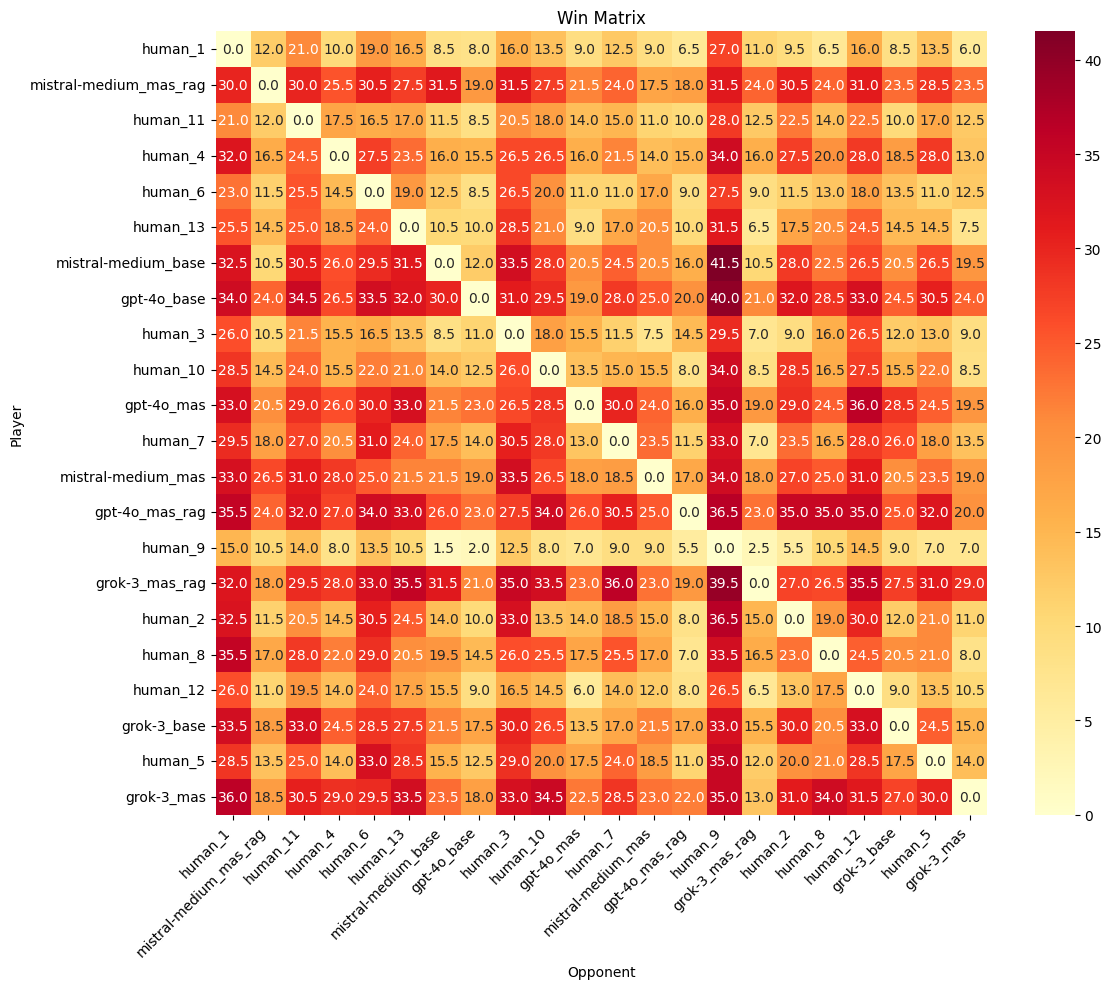

In [73]:
plt.figure(figsize=(12, 10))
sns.heatmap(W, xticklabels=unique_speakers, yticklabels=unique_speakers, annot=True, fmt=".1f", cmap="YlOrRd")
plt.xlabel("Opponent")
plt.ylabel("Player")
plt.title("Win Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [74]:
# Convert win matrix to pairwise comparison data for choix
params = choix.ilsr_pairwise_dense(W, alpha=0.01)

# Convert to DataFrame for readability
rankings = pd.DataFrame({
    "speaker": unique_speakers,
    "score": params
}).sort_values("score", ascending=False).reset_index(drop=True)

print(rankings)

                   speaker     score
0           gpt-4o_mas_rag  0.854890
1           grok-3_mas_rag  0.828564
2              gpt-4o_base  0.757146
3               grok-3_mas  0.678397
4               gpt-4o_mas  0.552415
5   mistral-medium_mas_rag  0.522234
6       mistral-medium_mas  0.353773
7      mistral-medium_base  0.333244
8              grok-3_base  0.282744
9                  human_4  0.089740
10                 human_7  0.059201
11                 human_8  0.051175
12                 human_5 -0.019235
13                 human_2 -0.171686
14                human_10 -0.238229
15                human_13 -0.325191
16                human_11 -0.523964
17                 human_6 -0.554012
18                 human_3 -0.622391
19                human_12 -0.658734
20                 human_1 -0.890844
21                 human_9 -1.359237
